In [1]:
import pandas as pd
import bar_chart_race as bcr
from utils.db_connector import get_engine

engine = get_engine()

Konekcija kreirana: localhost/smart_store


In [3]:
# Učitaj podatke za Top 10 States
df_states = pd.read_sql("""
    SELECT 
        c.full_date,
        g.state_or_province,
        SUM(f.sales) as sales
    FROM fact_orders f
    JOIN dim_calendar c ON c.date_id = f.order_date_id
    JOIN dim_geography g ON g.geography_id = f.geography_id
    GROUP BY c.full_date, g.state_or_province
    ORDER BY c.full_date
""", engine)

# Pivot tabela
pivot = df_states.pivot_table(
    index='full_date',
    columns='state_or_province',
    values='sales',
    aggfunc='sum'
).fillna(0)

# Kumulativna suma
pivot_cumsum = pivot.cumsum()

print(f"✅ Podaci učitani: {pivot_cumsum.shape}")

✅ Podaci učitani: (363, 49)


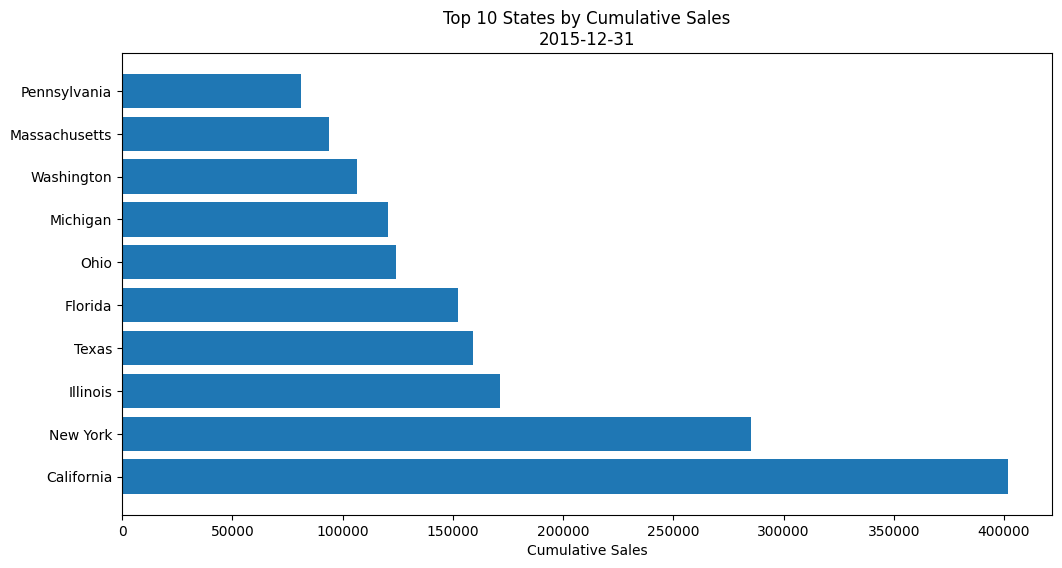

In [4]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(12, 6))

def animate(i):
    ax.clear()
    date = pivot_cumsum.index[i]
    data = pivot_cumsum.iloc[i].nlargest(10)
    
    ax.barh(data.index, data.values)
    ax.set_title(f'Top 10 States by Cumulative Sales\n{date}')
    ax.set_xlabel('Cumulative Sales')

ani = animation.FuncAnimation(
    fig, animate, 
    frames=len(pivot_cumsum),
    interval=100
)

ani.save('exports/top10_states_sales.gif', writer='pillow', fps=10)
plt.show()

In [5]:
# Učitaj podatke za Order Priority po sedmici
df_priority = pd.read_sql("""
    SELECT 
        c.week_number,
        c.year,
        o.order_priority,
        SUM(f.profit) as profit
    FROM fact_orders f
    JOIN dim_calendar c ON c.date_id = f.order_date_id
    JOIN dim_orderpriority o ON o.orderpriority_id = f.orderpriority_id
    GROUP BY c.year, c.week_number, o.order_priority
    ORDER BY c.year, c.week_number
""", engine)

# Dodaj year_week kolonu za sortiranje
df_priority['year_week'] = df_priority['year'].astype(str) + '-W' + df_priority['week_number'].astype(str).str.zfill(2)

# Pivot tabela
pivot_priority = df_priority.pivot_table(
    index='year_week',
    columns='order_priority',
    values='profit',
    aggfunc='sum'
).fillna(0)

# Kumulativna suma
pivot_priority_cumsum = pivot_priority.cumsum()

print(f"✅ Podaci učitani: {pivot_priority_cumsum.shape}")
print(pivot_priority_cumsum.head())

✅ Podaci učitani: (53, 5)
order_priority  Critical     High       Low   Medium  Not Specified
year_week                                                          
2015-W00         -607.47  1343.46  -1453.07  2595.07        -949.11
2015-W01       -12734.46  3142.79  -4558.58  -185.34        -278.93
2015-W02       -11161.46  1533.76  -4583.93  1571.26       -1686.12
2015-W03       -10310.38   764.82   3690.02  4391.42       -1340.11
2015-W04       -18149.67   303.16  14300.97  1883.99        2705.16


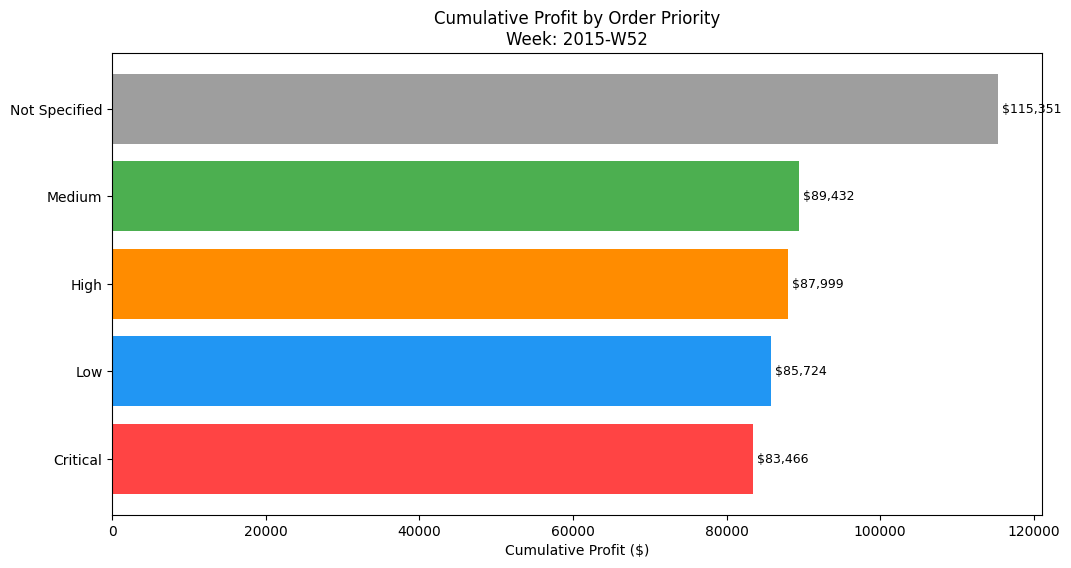

✅ GIF sačuvan!


In [6]:
fig2, ax2 = plt.subplots(figsize=(12, 6))

colors = {
    'Critical': '#FF4444',
    'High': '#FF8C00',
    'Medium': '#4CAF50',
    'Low': '#2196F3',
    'Not Specified': '#9E9E9E'
}

def animate_priority(i):
    ax2.clear()
    week = pivot_priority_cumsum.index[i]
    data = pivot_priority_cumsum.iloc[i].sort_values(ascending=True)
    
    bar_colors = [colors.get(p, '#9E9E9E') for p in data.index]
    
    ax2.barh(data.index, data.values, color=bar_colors)
    ax2.set_title(f'Cumulative Profit by Order Priority\nWeek: {week}')
    ax2.set_xlabel('Cumulative Profit ($)')
    
    for j, val in enumerate(data.values):
        ax2.text(val, j, f' ${val:,.0f}', va='center', fontsize=9)

ani_priority = animation.FuncAnimation(
    fig2, animate_priority,
    frames=len(pivot_priority_cumsum),
    interval=200
)

ani_priority.save('exports/priority_profit_race.gif', writer='pillow', fps=5)
plt.show()
print("✅ GIF sačuvan!")

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
from utils.db_connector import get_engine

engine = get_engine()
print("Imports uspešni!")

Konekcija kreirana: localhost/smart_store
Imports uspešni!


In [3]:
# Učitaj podatke iz MySQL sa svim potrebnim featurima
df = pd.read_sql("""
    SELECT 
        f.sales,
        f.discount,
        f.quantity,
        f.shipping_cost,
        f.unit_price,
        f.profit,
        p.product_category,
        p.product_sub_category,
        g.region,
        sm.ship_mode,
        op.order_priority
    FROM fact_orders f
    JOIN dim_product p ON p.product_key = f.product_id
    JOIN dim_geography g ON g.geography_id = f.geography_id
    JOIN dim_shipmode sm ON sm.shipmode_id = f.shipmode_id
    JOIN dim_orderpriority op ON op.orderpriority_id = f.orderpriority_id
""", engine)

print(f"Učitano {len(df)} redova")
print(f"\nKolone: {df.columns.tolist()}")
print(f"\nPrvih 5 redova:")
df.head()

Učitano 2851 redova

Kolone: ['sales', 'discount', 'quantity', 'shipping_cost', 'unit_price', 'profit', 'product_category', 'product_sub_category', 'region', 'ship_mode', 'order_priority']

Prvih 5 redova:


,sales,discount,quantity,shipping_cost,unit_price,profit,product_category,product_sub_category,region,ship_mode,order_priority
0,236.87,0.04,75,0.99,3.08,36.02,Office Supplies,Labels,Central,Regular Air,Critical
1,370.91,0.02,53,5.90,6.48,-50.64,Office Supplies,Paper,Central,Regular Air,Critical
2,4976.92,0.04,47,4.20,125.99,510.49,Technology,Telephones and Communication,Central,Regular Air,Critical
3,73.97,0.01,20,1.86,3.26,-4.67,Office Supplies,Pens & Art Supplies,South,Regular Air,Critical
4,232.50,0.05,35,8.73,6.48,-160.38,Office Supplies,Paper,South,Regular Air,Critical


In [4]:
# Encode kategoričke kolone u brojeve
le = LabelEncoder()
categorical_cols = ['product_category', 'product_sub_category', 
                    'region', 'ship_mode', 'order_priority']

df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Features i target
X = df_encoded.drop('profit', axis=1)
y = df_encoded['profit']

print(f"Features: {X.columns.tolist()}")
print(f"Target: profit")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train/Test split — 80% trening, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n Train size: {len(X_train)} redova")
print(f" Test size:  {len(X_test)} redova")

Features: ['sales', 'discount', 'quantity', 'shipping_cost', 'unit_price', 'product_category', 'product_sub_category', 'region', 'ship_mode', 'order_priority']
Target: profit
X shape: (2851, 10)
y shape: (2851,)

 Train size: 2280 redova
 Test size:  571 redova


In [7]:
# Kreiraj i treniraj Random Forest model
print("Treniram model...")

model = RandomForestRegressor(
    n_estimators=100,   # broj stabala u šumi
    max_depth=10,       # maksimalna dubina stabla
    random_state=42     # reproduktibilnost rezultata
)

model.fit(X_train, y_train)
print("Model istreniran!")

# Predikcija na test setu
y_pred = model.predict(X_test)

# Evaluacija
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\nRezultati modela:")
print(f"MAE  (Mean Absolute Error): ${mae:.2f}")
print(f"RMSE (Root Mean Sq. Error): ${rmse:.2f}")
print(f"R2   Score:                 {r2:.3f}")

Treniram model...
Model istreniran!

Rezultati modela:
MAE  (Mean Absolute Error): $266.65
RMSE (Root Mean Sq. Error): $838.95
R2   Score:                 0.271


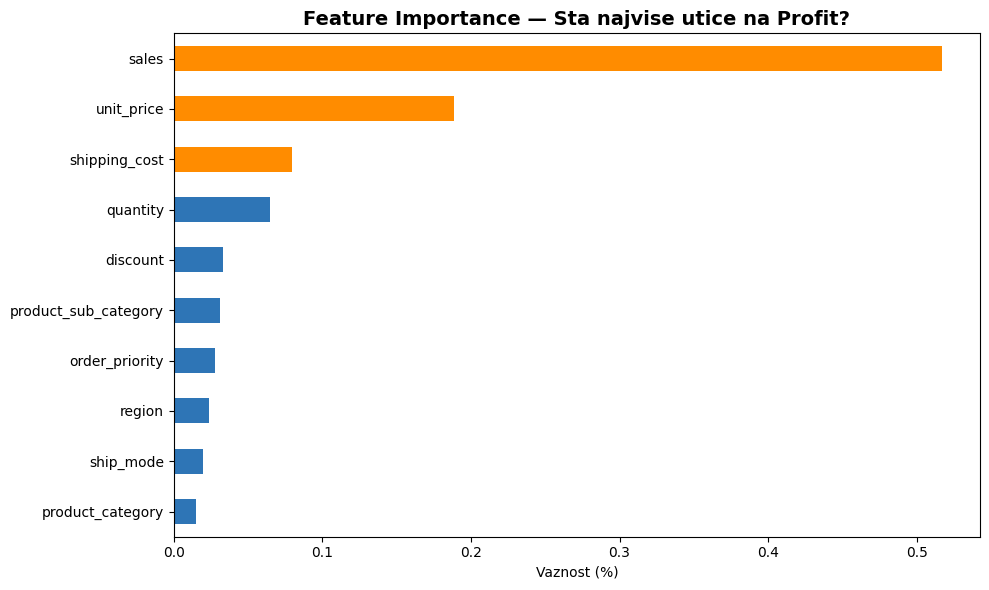

Feature Importance sačuvan!

Top 3 najvaznije features:
shipping_cost    0.079587
unit_price       0.188337
sales            0.516757
dtype: float64


In [9]:
# Feature Importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#2E75B6' if i < len(importance)-3 
          else '#FF8C00' for i in range(len(importance))]
importance.plot(kind='barh', color=colors)
plt.title('Feature Importance — Sta najvise utice na Profit?',
          fontsize=14, fontweight='bold')
plt.xlabel('Vaznost (%)')
plt.tight_layout()
plt.savefig('exports/feature_importance.png', dpi=150)
plt.show()
print("Feature Importance sačuvan!")
print("\nTop 3 najvaznije features:")
print(importance.tail(3))